In [10]:
#These are the dataset given to us from kagglehub 
#https://www.kaggle.com/datasets/mslatifpour/iris-dataset
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

iris = pd.read_csv("iris.csv")

iris.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
#Let's start with the gbm

#Here's our x and y values
x = iris[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]
y = iris["Species"]

In [12]:
#Split the data to use for training and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

#test_size = puts 20% of data for testing, the rest for training
#random_state = controls the randomness, 42 is just a commonly used number for here
#stratify=y = helps keeps the class proportion balanced

In [15]:
#Create the GBM
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate= 0.1,
    max_depth=3,
    random_state=42
)

#n_estimators = how many trees
#learning_rate = how much does each tree contribute
#max_depth = how complicated each tree is
#random_state = controls the randomness

In [17]:
#Model of the training data
model.fit(x_train, y_train)

#Making a model of the predicted (test) data
y_pred = model.predict(x_test)

In [18]:
#Checking out the accuracy of our data
print("Accuracy:", accuracy_score(y_test, y_pred))

#Confusion Matrix of our data
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9666666666666667
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


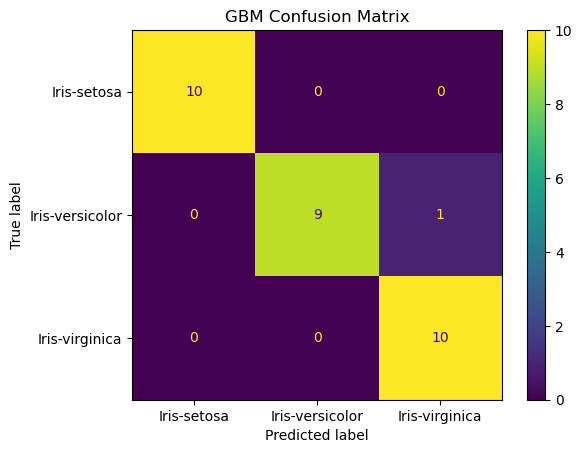

In [22]:
#We can also visualize it
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("GBM Confusion Matrix")
plt.show()

In [19]:
#Based on the results above

#Accuracy of our model is 96.6%
#10 Setosa correctly preidcted
#0 Setosa incorrectly predicted as Versicolor and Virginica
#9 Versicolor correctly predicted
#0 Versicolor incorrectly predicted as Setosa, and 1 Versicolor incorrectly predicted as Virginica
#10 Virginica correctly predicted
#0 Virginica incorrectly predicted as Setosa and Versicolor

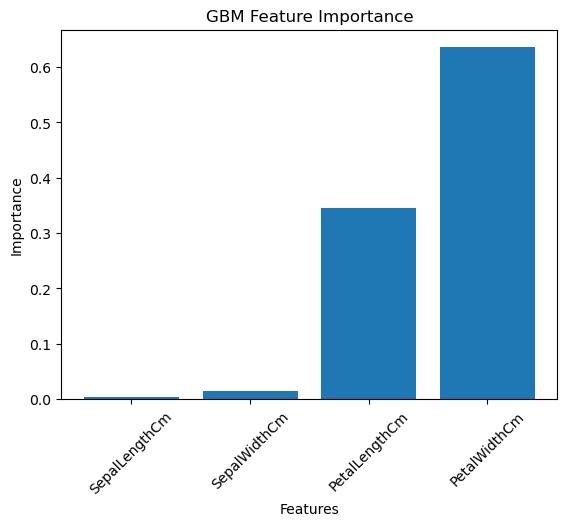

In [20]:
#The best way to visualize GBM is to bar plot for your feature importance (variables)

importance = model.feature_importances_

plt.bar(x.columns, importance)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("GBM Feature Importance")
plt.xticks(rotation=45)
plt.show()

#xticks = rotates the plots by 45 degrees

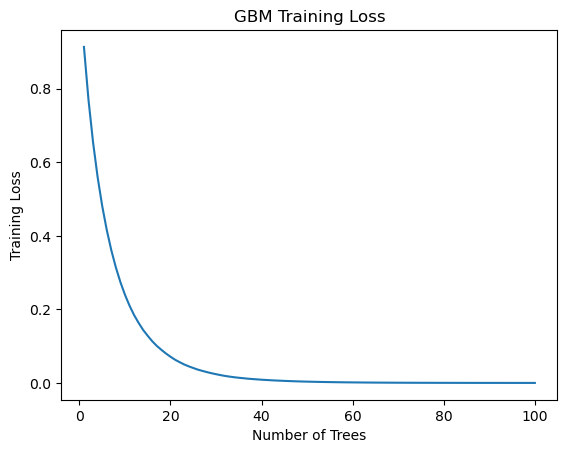

In [24]:
#Since GBM is built on trees, we can look at the training loss
train_score = model.train_score_

plt.plot(range(1, len(train_score) + 1), train_score)
plt.xlabel("Number of Trees")
plt.ylabel("Training Loss")
plt.title("GBM Training Loss")
plt.show()

#Training loss = about how much prediction error the loss function measures

In [25]:
#As you can see, around x = 20 trees, the GBM would produce around 0.1 training loss

In [31]:
#Let's predict with random values
sample = [[5.1, 3.5, 1.4, 0.2]]

sample_iris = pd.DataFrame(
    sample,
    columns=["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]
)

prediction = model.predict(sample_iris)

print(prediction[0])


Iris-setosa


In [ ]:
#Recap: We use GBM when we are given a strcutured/tabular data